# Smart Default Plots in Symbulate

**One call. Zero arguments. The right plot for your data.**

Students using Symbulate shouldn't need to know a plot taxonomy before they can *see*
their simulation. So `.plot()` now inspects the simulated data — how many variables,
whether each looks **discrete or continuous**, and whether the sample is **small or
large** — and picks a sensible default from the team's lookup table.

Three ideas run through everything in this demo:

1. **Small samples show individual observations; large samples show the
   distribution.** The same call adapts as evidence accumulates.
2. **A note under the plot tells you what you're seeing** — and which alternatives
   are one `type=` keyword away.
3. **It composes.** Two `.plot()` calls on one figure overlay automatically, in
   distinct colorblind-safe colors.

## The lookup table at a glance

| Configuration | Small-`n` default | Large-`n` default |
|---|---|---|
| 1D discrete | dot plot | impulse plot |
| 1D continuous | rug plot | histogram |
| 1D categorical (strings) | dot plot | bar chart |
| 2D discrete × discrete | scatter (with jitter) | tile plot |
| 2D continuous × continuous | scatter | 2D histogram |
| 2D mixed (discrete × continuous) | segmented rug | tile plot |

Each configuration has its own section below.

In [1]:
%matplotlib inline
import numpy as np
from symbulate import *

np.random.seed(2026)  # so the presentation renders identically every run

## 1D discrete

Roll two dice and take the sum — a single numeric variable with only a few
possible values.

**Small `n` → dot plot (default)**

Currently Showing: Dot Plot (Default)
Alternative Plots: Impulse Plot (type = "impulse"), Histogram (type = "hist"), ECDF Plot (type = "ecdf")


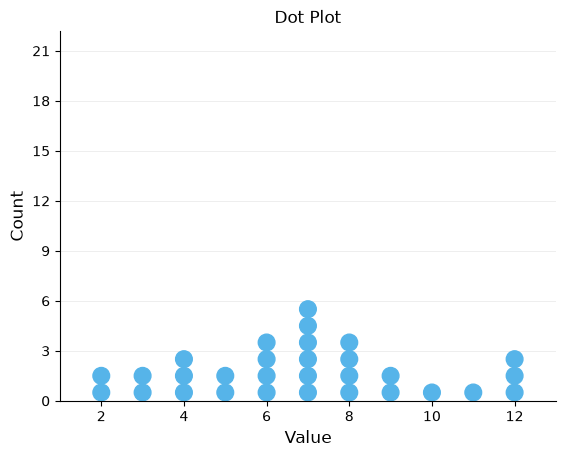

In [2]:
roll = RV(BoxModel([1, 2, 3, 4, 5, 6], size=2), sum)

roll.sim(30).plot()

Every one of the 30 rolls is its own dot, stacked and countable — exactly what a
small sample deserves.

And notice the note that just printed. Symbulate names the plot it chose and lists
the reasonable alternatives for *this* data. (It prints once per session; pass
`suggest=True` to always see it, `suggest=False` to silence it.)

**Large `n` → impulse plot (default)**

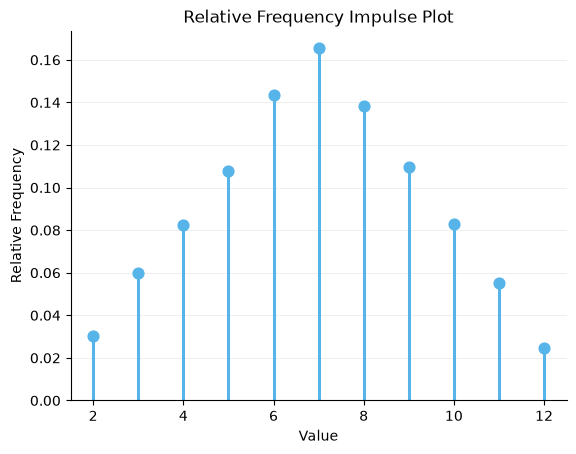

In [3]:
roll.sim(3000).plot()

With a large sample, individual dots would be noise — so the default shifts to an
impulse plot, and the triangular distribution of a two-dice sum snaps into view.
Nobody changed any plotting code between those two cells.

## 1D continuous

Spin a fair spinner four times and average the spins — the Central Limit Theorem
in two calls.

**Small `n` → rug plot (default)**

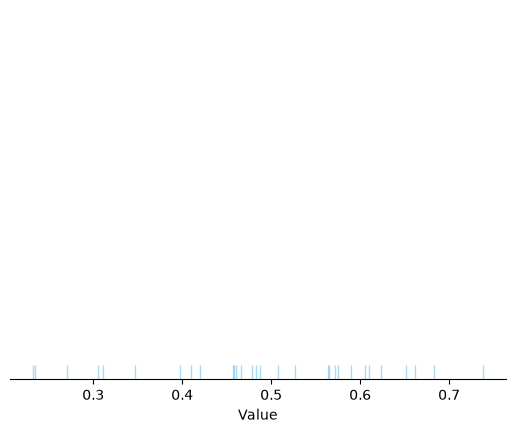

In [4]:
avg_spin = RV(Uniform(0, 1) ** 4, lambda spins: sum(spins) / 4)

avg_spin.sim(30).plot()

**Large `n` → histogram (default)**

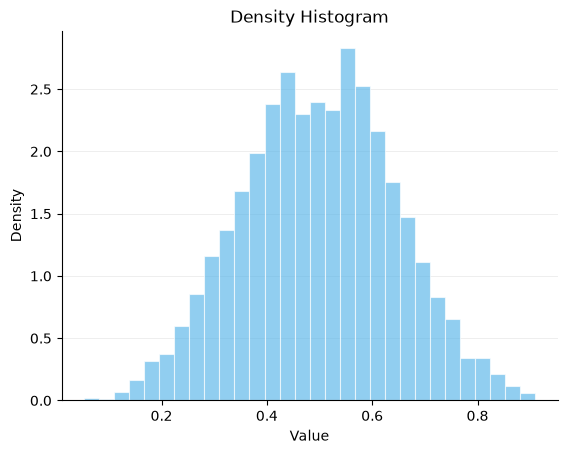

In [5]:
avg_spin.sim(3000).plot()

Continuous data gets a rug plot while the sample is small — one tick per
observation on a number line — and a histogram once it's large, where the CLT's
bell shape emerges from averaging flat uniform spins.

## 1D categorical

Outcomes don't have to be numbers. Model the blood type of a random donor (US
frequencies).

**Small `n` → dot plot (default)**

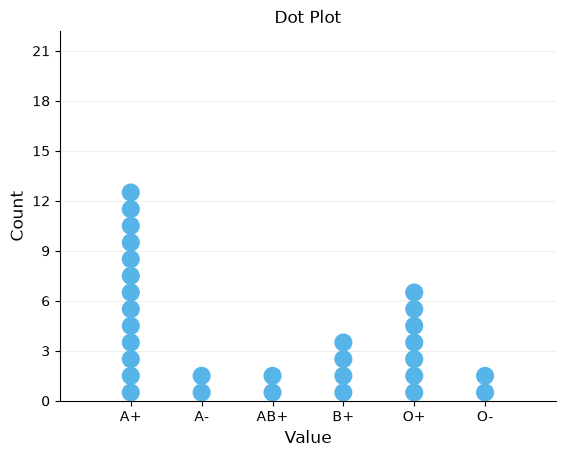

In [6]:
donor = RV(
    BoxModel(
        ["O+", "A+", "B+", "AB+", "O-", "A-", "B-", "AB-"],
        probs=[0.38, 0.34, 0.09, 0.03, 0.07, 0.06, 0.02, 0.01],
    )
)

donor.sim(30).plot()

**Large `n` → bar chart (default)**

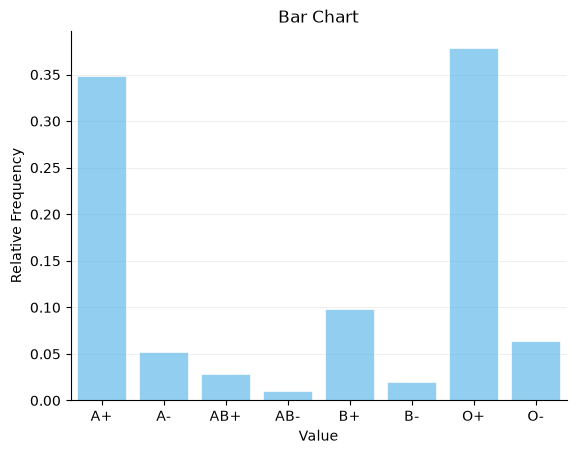

In [7]:
donor.sim(2000).plot()

Categorical outcomes plot directly — no `.tabulate()` detour needed just to see the
distribution. One glance answers a real question: the universal donor, O−, is the
type blood banks chase — and the simulation shows why, its bar landing near 7%
while O+ and A+ tower over everything else.

## 2D discrete × discrete

Simulate a *pair* and the lookup table considers both variables. Flip a coin 8
times: let X = heads in the **first 4 flips**, Y = heads in **all 8**. The pair is
dependent — the total remembers its first half.

**Small `n` → scatter with countable jitter (default)**

Currently Using: jitter="spiral" (points sharing a value form a tight, countable cluster)
Other Jitter Options: jitter="bins" (points sharing a value fill that value's box, like a tiny dot histogram), jitter="random" (small random noise), jitter=False (exact positions -- repeated points draw on top of each other)


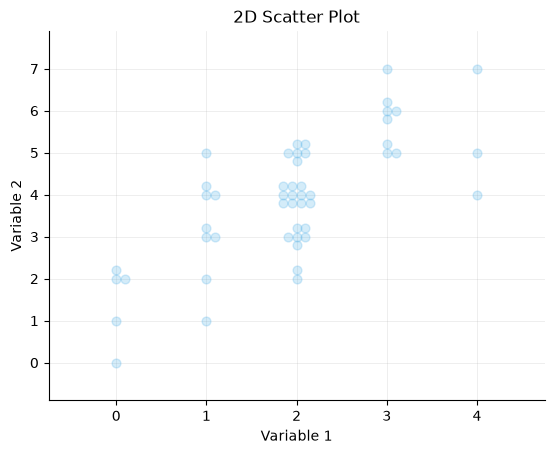

In [8]:
flips = BoxModel([0, 1], size=8)
first_half = RV(flips, lambda f: sum(f[:4]))
total = RV(flips, sum)

(first_half & total).sim(50).plot()

Coincident rounds cluster tightly *on* their grid crossing, so you can still count
them, and the diagonal trend already shows. (The second note explains the jitter
layout and its options.)

**Large `n` → tile plot (default)**

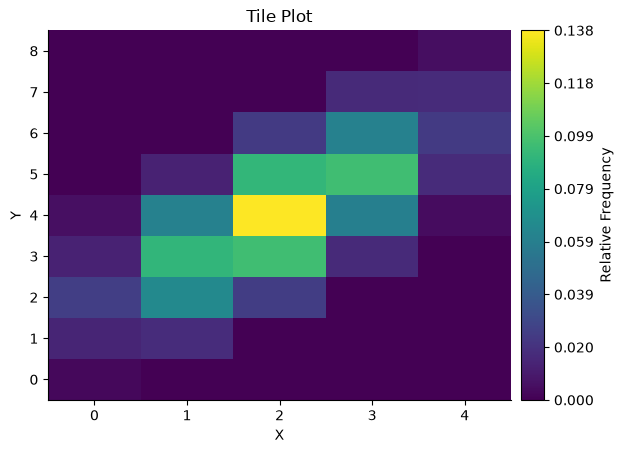

In [9]:
(first_half & total).sim(5000).plot()

At 5,000 rounds, counting dots stops making sense, so color carries the frequency
instead. Impossible combinations (a total smaller than its own first half) stay
dark at zero, and the likeliest cell — 2 heads then 4 total — glows brightest.

## 2D continuous × continuous

Two continuous variables — say, midterm and final exam scores with correlation 0.6.

**Small `n` → scatter (default)**

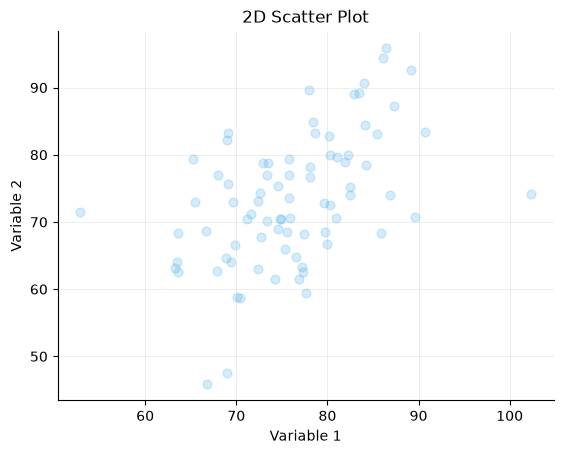

In [10]:
midterm, final = RV(BivariateNormal(mean1=75, mean2=72, sd1=8, sd2=10, corr=0.6))

(midterm & final).sim(80).plot()

**Large `n` → 2D histogram (default)**

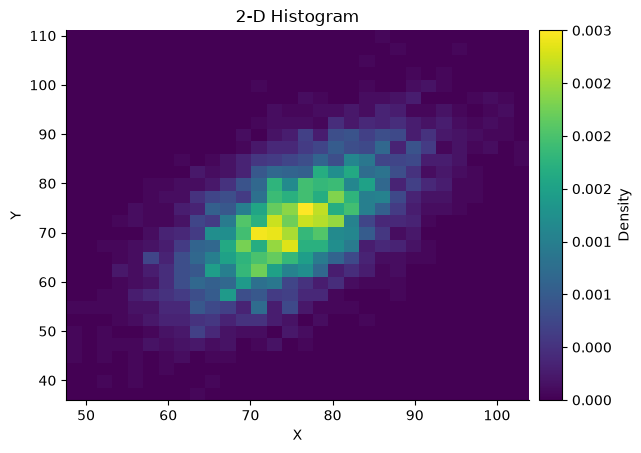

In [11]:
scores = (midterm & final).sim(5000)

scores.plot()

Same simulation, two more looks — one keyword each. `hex=True` swaps the square
bins for hexagons:

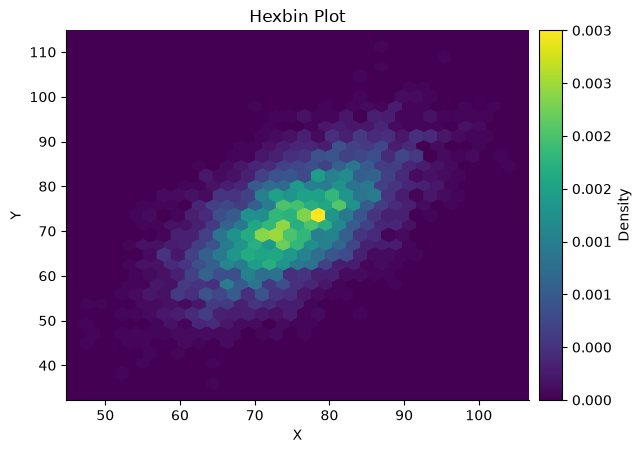

In [12]:
scores.plot(hex=True)

...and asking for the density with `contour=True` estimates the smooth surface
underneath the data and draws it like a topographic map:

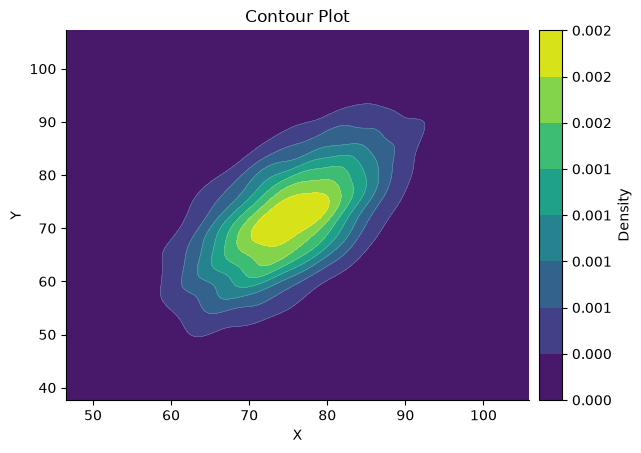

In [13]:
scores.plot(type="density", contour=True)

## 2D mixed (discrete × continuous)

One discrete and one continuous variable. Say a player attempts three
three-pointers per game (X = shots made), and the game's scoring margin lands
within a point or so of 3 points per make (continuous noise).

**Small `n` → segmented rug (default)**

Currently Showing: Rug Plot (Default)
Alternative Plots: Tile Plot (type = "tile"), Box Plot (type = "box"), Violin Plot (type = "violin"), Density Plot (type = "density"), Histogram (type = "hist")


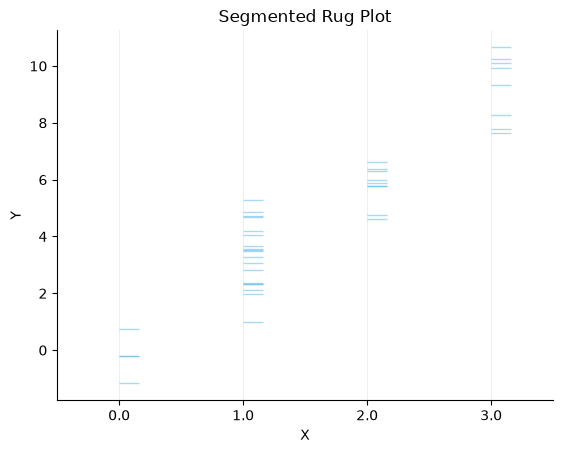

In [14]:
P = Binomial(3, 0.5) * Normal(0, 1)
made = RV(P, lambda outcome: outcome[0])
score = RV(P, lambda outcome: 3 * outcome[0] + outcome[1])

(made & score).sim(40).plot(suggest=True)

One band per number of shots made, every game visible as a tick.

**Large `n` → tile plot (default)**

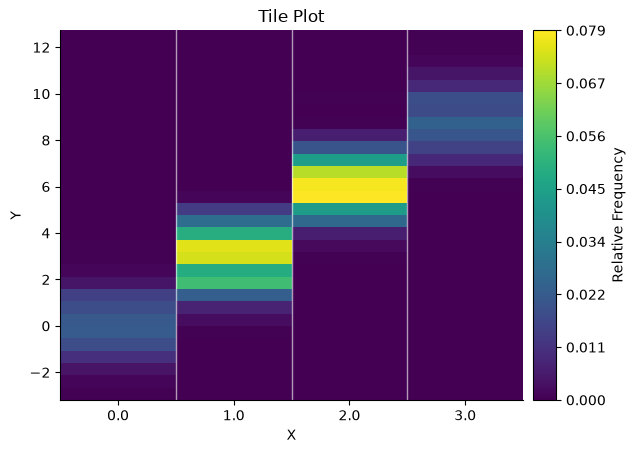

In [15]:
(made & score).sim(2000).plot()

### The note is a menu — follow it

The note above says a **density plot** is one keyword away. On mixed data that
means one small density curve per level, stacked on shared baselines. Listing the
continuous variable first puts the discrete one on the y-axis — the classic
ridgeline orientation:

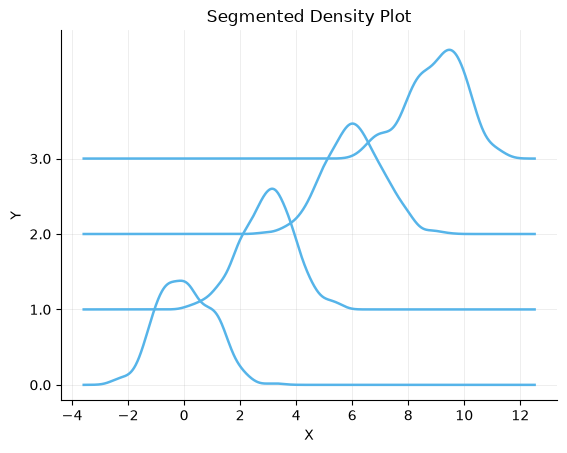

In [16]:
games = (score & made).sim(2000)

games.plot(type="density")

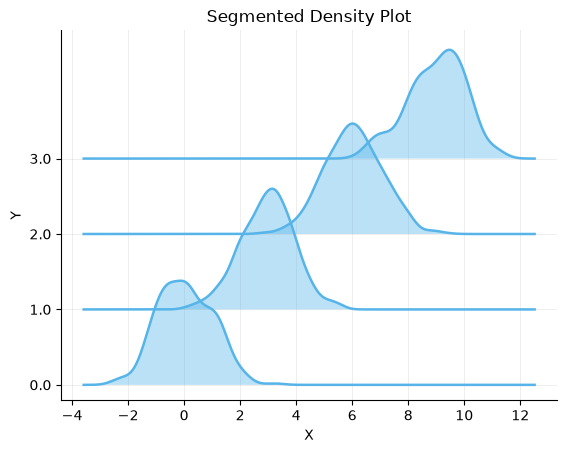

In [17]:
# ...and ridge=True fills under each curve, for the classic ridgeline look
games.plot(type="density", ridge=True)

Every level's curve shares one density scale, so a taller peak really is a taller
density — the score distribution marches upward as more shots go in.

## Overlays come free

Comparing two models is just two `.plot()` calls in one cell. Each picks the next
colorblind-safe color automatically and a legend appears. One spinner spin vs. the
average of four — averaging tames randomness:

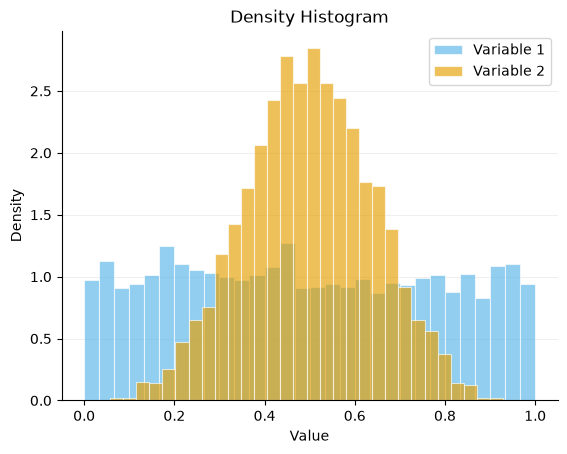

In [18]:
one_spin = RV(Uniform(0, 1))

one_spin.sim(3000).plot()
avg_spin.sim(3000).plot()

The same trick works in 2D. Overlay two class sections' exam scores — each
`.plot()` call takes the next color, and a legend appears so the clouds stay
distinguishable:

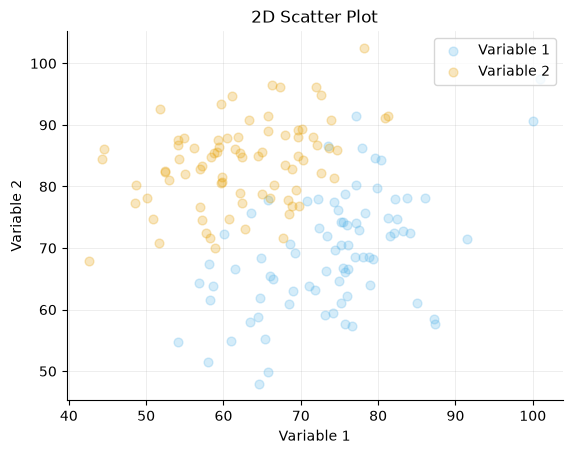

In [19]:
section_A = (midterm & final).sim(80)

mid_B, fin_B = RV(BivariateNormal(mean1=62, mean2=85, sd1=8, sd2=6, corr=0.2))
section_B = (mid_B & fin_B).sim(80)

section_A.plot()
section_B.plot()

Even the segmented plots overlay level-by-level, because every call shares the
same baselines and density scale. Compare our shooter with a *streakier*
teammate — same 50% shooting, but wilder game-to-game scoring:

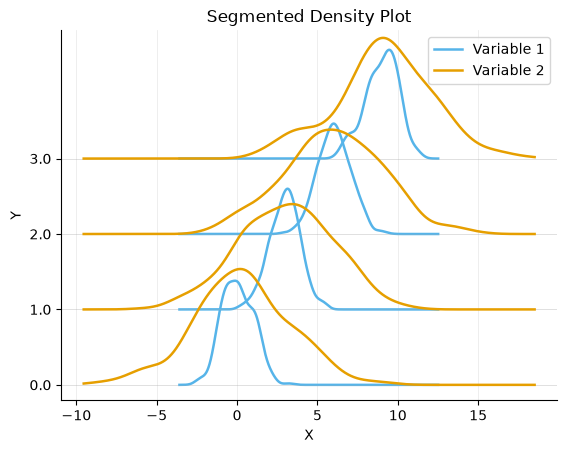

In [20]:
streaky = Binomial(3, 0.5) * Normal(0, 3)
s_made = RV(streaky, lambda outcome: outcome[0])
s_score = RV(streaky, lambda outcome: 3 * outcome[0] + outcome[1])

games.plot(type="density")
(s_score & s_made).sim(2000).plot(type="density")

At every number of shots made, the two curves sit on the same center — the
players average the same — but the orange curves are visibly wider: the streaky
player's score tells you much less about how the game actually went.

## Recap

- `.plot()` chooses a default from the **data configuration** and **sample
  size** (see the lookup table at the top); the default shifts as `n` grows
  (dot plot → impulse, rug → histogram, scatter → tile / 2D histogram).
- **Alternatives are one keyword away** — `type="density"`, `type="box"`,
  `type="violin"`, ... exactly as the note suggests, plus variants like
  `hex=True` (hexagonal bins), `contour=True` (topographic density), and
  `ridge=True` (filled ridgeline).
- **Overlays, colors, and styling are automatic** — Okabe-Ito colorblind-safe
  palette, shared axes, legends on demand.

## Alternative Plots

Every default has a bench behind it — each of these is the same simulated data
from the sections above, re-asked with one `type=` keyword.

**Violin plot** — the shots-made × score pair, one violin per level:

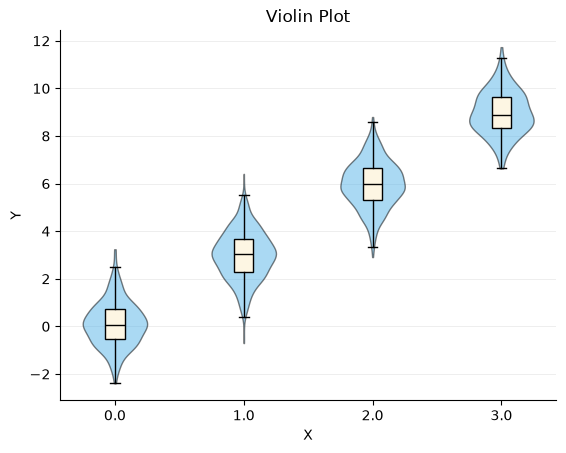

In [21]:
(made & score).sim(2000).plot(type="violin")

**Box plot** — same data, the five-number summary per level:

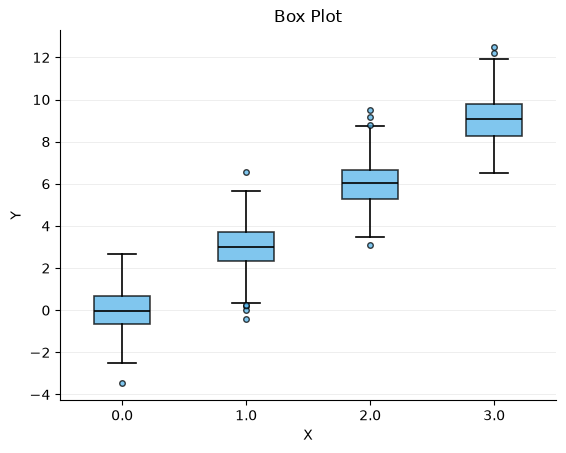

In [22]:
(made & score).sim(2000).plot(type="box")

**Mosaic plot** (new from `dev`) — the coin-flip pair: column widths show how
often each first-half count occurred, and the colored segments show the share
of each total within that column:

/Users/roland/Documents/calpoly-symbulate/symbulate/results.py:1807: UserWarning: This mosaic plot has 9 distinct y-values, more than the 7 colors in the categorical palette, so some categories repeat a color (distinguished with a hatch pattern instead). A mosaic plot is hard to read with this many categories -- consider a plot type that doesn't rely on category color, like a tile plot.
  make_mosaic(x, y, ax, normalize=normalize, **kwargs)


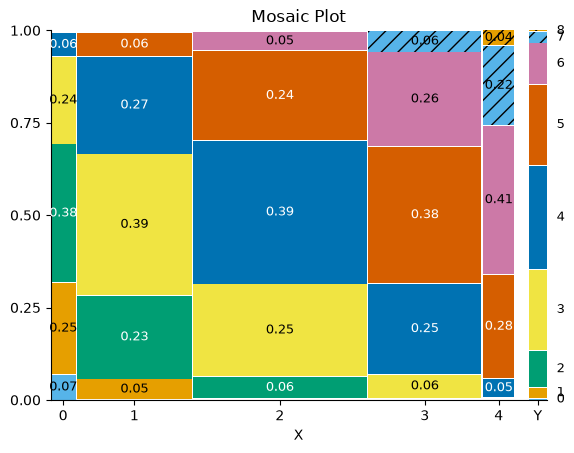

In [23]:
(first_half & total).sim(5000).plot(type="mosaic")

**ECDF plot** — the spinner averages as a cumulative relative frequency curve:

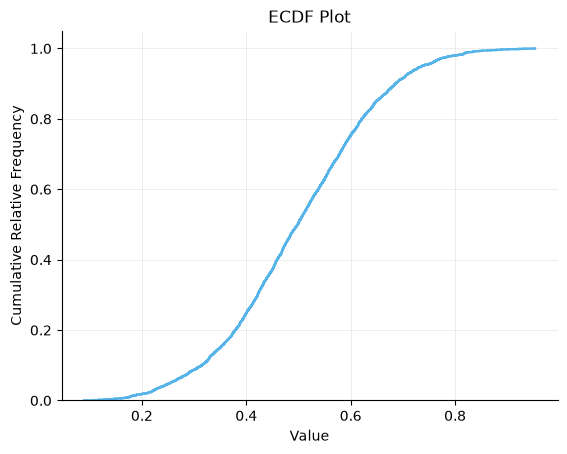

In [24]:
avg_spin.sim(3000).plot(type="ecdf")

**Segmented histogram** — the ridgeline layout with a small histogram per
level, all sharing one set of bin edges:

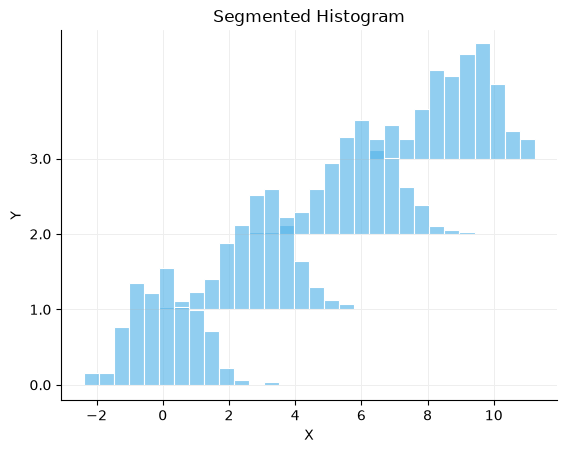

In [25]:
games.plot(type="segmented_hist")

**Segmented density** — the explicit name for the density ridges shown earlier
(on mixed data, plain `type="density"` resolves to it):

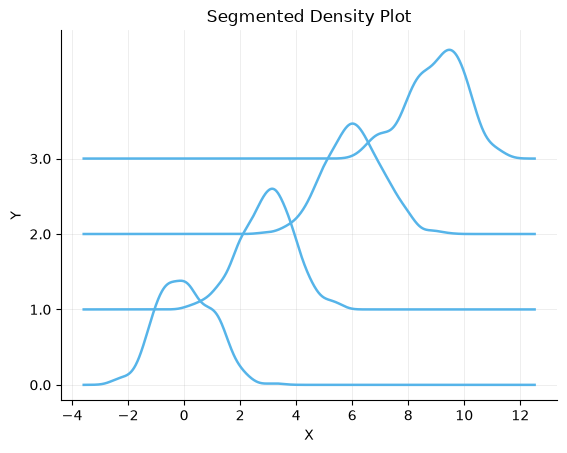

In [26]:
games.plot(type="segmented_density")